In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


#https://yann.lecun.com/exdb/mnist/

In [55]:
class LeNet(torch.nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 6, kernel_size=5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(6, 16, kernel_size=5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )
        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(16, 120, kernel_size=5),
            torch.nn.ReLU(),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(120, 84),
            torch.nn.Linear(84, 10),
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv1(x)  # 一层卷积层,一层池化层,一层激活层(图是先卷积后激活再池化，差别不大)
        x = self.conv2(x)  # 再来一次
        x = self.conv3(x)  # 再来一次
        x = x.view(batch_size, -1)  # flatten 变成全连接网络需要的输入 (batch, 120,1,1) ==> (batch,120), -1 此处自动算出的是120
        x = self.fc(x)
        return x  # 最后输出的是维度为10的，也就是（对应数学符号的0~9）


三层全连接网络

In [56]:

# 定义一个简单的神经网络
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)  # 展平输入
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


In [57]:
from torchsummary import summary

# 查看模型的内存使用
#summary(LeNet(),input_size=(1,32,32))
summary(SimpleNN(),input_size=(28*28,))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]         100,480
              ReLU-2                  [-1, 128]               0
            Linear-3                   [-1, 64]           8,256
              ReLU-4                   [-1, 64]               0
            Linear-5                   [-1, 10]             650
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.42
Estimated Total Size (MB): 0.42
----------------------------------------------------------------


In [58]:

# 创建数据加载器
def create_data_loaders(batch_size=64):
    
    transform = transforms.Compose([
        #全连接网络的输入是一个一维张量（784=28*28），可以把下面这行注释掉
        transforms.Resize((32,32)), #CNN的输入：32行32列的图像，这里转成二维的时候做了padding
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


In [59]:

# 训练模型的函数
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    losses = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    return losses

# 绘制损失曲线的函数
def plot_losses(losses):
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs-20250321')
    plt.legend()
    plt.show()


In [60]:

# 测试模型的函数
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
    return accuracy


In [61]:

# 推理模型的函数，并输出测试图片
def infer_model_and_display_image(model, test_loader):
    model.eval()
    sample_input, true_label = next(iter(test_loader))  # 获取一个样本
    sample_input = sample_input[:1]  # 取第一个样本
    true_label = true_label[:1]

    with torch.no_grad():
        output = model(sample_input)
        _, predicted = torch.max(output.data, 1)

    # 显示图片和预测结果
    plt.figure(figsize=(5, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_input.squeeze().numpy(), cmap='gray')
    plt.title(f'True Label: {true_label.item()}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.5, f'Predicted Label: {predicted.item()}', fontsize=12, ha='center', va='center')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return predicted.item()


Epoch [1/10], Loss: 0.2039
Epoch [2/10], Loss: 0.0603
Epoch [3/10], Loss: 0.0438
Epoch [4/10], Loss: 0.0349
Epoch [5/10], Loss: 0.0288
Epoch [6/10], Loss: 0.0240
Epoch [7/10], Loss: 0.0204
Epoch [8/10], Loss: 0.0173
Epoch [9/10], Loss: 0.0159
Epoch [10/10], Loss: 0.0140


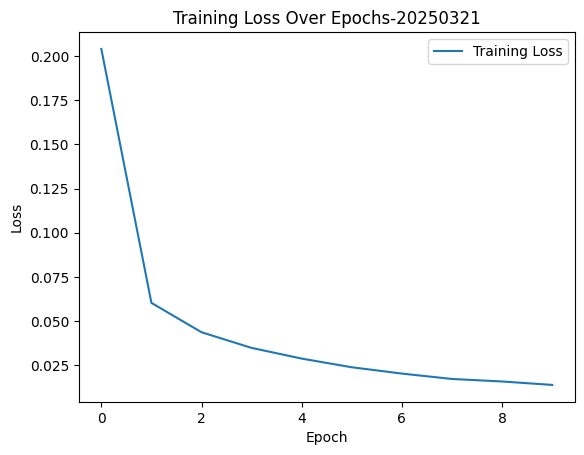

Accuracy of the network on the test images: 98.76%


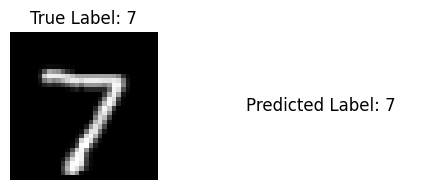

In [62]:

# 主函数，整合训练、测试和推理
def main():
    # 设置超参数
    batch_size = 64
    learning_rate = 0.001
    num_epochs = 10

    # 创建数据加载器
    train_loader, test_loader = create_data_loaders(batch_size=batch_size)

    # 初始化模型、损失函数和优化器
    #model = SimpleNN()
    model = LeNet()
 
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # 训练模型
    losses = train_model(model, train_loader, criterion, optimizer, num_epochs=num_epochs)

    # 绘制损失曲线
    plot_losses(losses)

    # 测试模型
    accuracy = evaluate_model(model, test_loader)

    # 推理模型并显示图片
    prediction = infer_model_and_display_image(model, test_loader)

if __name__ == "__main__":
    main()
